In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

/tmp/ipykernel_773418/2481774189.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data_path_events = Path("2023_event_sync")
event_data = pd.concat(pd.read_parquet(par_file) for par_file in data_path_events.glob('*.parquet'))


In [3]:
data_path_tracking = Path("2023_tracking_sync")
tracking_data = pd.concat(pd.read_parquet(par_file) for par_file in data_path_tracking.glob('*.parquet'))

In [4]:
tracking_data.columns

Index(['team_id', 'team', 'jersey_number', 'player', 'role', 'speed',
       'x_signality', 'y_signality', 'vx_signality', 'vy_signality',
       'x_adjusted', 'y_adjusted', 'pitch_length', 'pitch_width',
       'team_direction', 'id', 'frame', 'minute', 'second', 'period',
       'start_frame', 'player_id_event', 'possession_team_id'],
      dtype='object')

In [5]:
tracking_data

,team_id,team,jersey_number,player,role,speed,x_signality,y_signality,vx_signality,vy_signality,...,pitch_width,team_direction,id,frame,minute,second,period,start_frame,player_id_event,possession_team_id
0,6736,home_team,19,Srdjan Hrstic,10,0.665,-0.63,-0.80,0,0,...,68,left,1720110584,5,45,3,2,4.577083,676584,6736
1,6736,home_team,11,Samuel Gustafson,7,0.588,9.16,0.05,0,0,...,68,left,1720110584,5,45,3,2,4.577083,676584,6736
2,6736,home_team,8,Abdulrazaq Ishaq,6,0.398,0.51,-10.78,0,0,...,68,left,1720110584,5,45,3,2,4.577083,676584,6736
3,6736,home_team,27,Akoua Romeo Amane,8,0.119,0.88,11.46,0,0,...,68,left,1720110584,5,45,3,2,4.577083,676584,6736
4,6736,home_team,5,Even Hovland,4,0.388,17.95,9.30,0,0,...,68,left,1720110584,5,45,3,2,4.577083,676584,6736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57460,6721,away_team,23,Niklas Hult,5,1.244,40.37,2.95,0,0,...,65,left,1625749005,77546,96,42,2,77546.078125,0,6754
57461,6721,away_team,30,Hákon Valdimarsson,1,0.942,48.82,-1.21,0,0,...,65,left,1625749005,77546,96,42,2,77546.078125,0,6754
57462,6721,away_team,29,Buhari Ibrahim,0,1.480,32.09,-18.97,0,0,...,65,left,1625749005,77546,96,42,2,77546.078125,0,6754
57463,6721,away_team,25,Jack Cooper-Love,0,3.137,21.71,-24.11,0,0,...,65,left,1625749005,77546,96,42,2,77546.078125,0,6754


### filteration of final third passes

In [4]:
events_data_pass = event_data[(event_data["end_x"] > 70) & (event_data['type'] == "pass") & (event_data['successful'] == True)]
tracking_data_pass = tracking_data[tracking_data['team_id'] != -1]

In [7]:
events_data_pass.shape

(35844, 151)

In [8]:
tracking_data_pass.shape

(13335044, 23)

### Frames with missing player

In [5]:
tracking_player_count = tracking_data_pass.groupby('id')['player'].count()
print(tracking_player_count)

id
1591807961    20
1591807962    44
1591807963    22
1591807964    21
1591807965    42
              ..
1835139713    22
1835139717    22
1835139718    22
1835139719    22
1835139720    22
Name: player, Length: 389800, dtype: int64


In [6]:
tracking_player_count.value_counts()

player
44    178274
22    118295
21     33332
42     31845
20      9129
40      6748
19      3302
38      2223
18      1453
88      1290
36       899
17       674
34       434
84       274
16       263
2        235
32       164
15       161
1        106
30       104
4         89
14        85
80        59
28        56
13        42
12        40
26        32
6         31
76        28
24        25
11        23
10        20
8         19
3         15
72        12
9          7
5          7
68         2
64         2
7          1
Name: count, dtype: int64

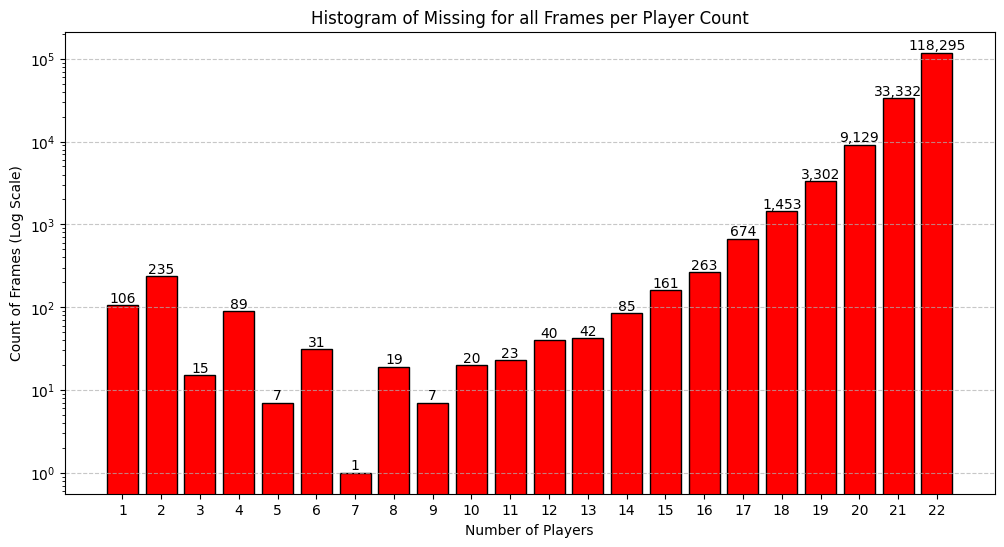

In [7]:
import matplotlib.pyplot as plt

missing_counts_all = tracking_player_count.value_counts().reindex(range(1, 23), fill_value=0)


# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(missing_counts_all.index, missing_counts_all.values, color='red', edgecolor='black')

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    if height > 0:  # Only label non-zero bars
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:,}', ha='center', va='bottom', fontsize=10, rotation=0)

# Use logarithmic scale if the difference is too large
plt.yscale('log')

# Labels and title
plt.xlabel('Number of Players')
plt.ylabel('Count of Frames (Log Scale)')
plt.title('Histogram of Missing for all Frames per Player Count')

# Improve x-axis ticks visibility
plt.xticks(range(1, 23))

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


## dropping duplicates player

In [11]:
tracking_data_cleaned = tracking_data_pass.drop_duplicates(subset=["id","player"])

In [12]:
tracking_data_cleaned['team'].value_counts()

home_team    4217063
away_team    4210709
ball               0
Name: team, dtype: int64

In [13]:
tracking_data_cleaned_player_count = tracking_data_cleaned.groupby('id')['player'].count()


In [14]:
tracking_data_cleaned_player_count.value_counts()

22    297642
21     65503
20     16014
19      5577
18      2361
17      1119
16       424
1        272
15       265
2        155
14       131
13        74
12        59
11        49
3         44
10        25
5         20
9         18
4         16
8         13
7         11
6          8
Name: player, dtype: int64

In [15]:
tracking_data_cleaned_player_count = tracking_data_cleaned_player_count[tracking_data_cleaned_player_count >= 21]

In [16]:
tracking_data_cleaned_player_count.value_counts()

22    297642
21     65503
Name: player, dtype: int64

In [17]:
tracking_data_cleaned_player_count.tolist

<bound method IndexOpsMixin.tolist of id
1591807962    22
1591807963    22
1591807964    21
1591807965    21
1591807966    22
              ..
1835139713    22
1835139717    22
1835139718    22
1835139719    22
1835139720    22
Name: player, Length: 363145, dtype: int64>

In [18]:
tracking_player_count = tracking_data_cleaned_player_count.reset_index()

In [20]:
tracking_player_count

,id,player
0,1591807962,22
1,1591807963,22
2,1591807964,21
3,1591807965,21
4,1591807966,22
...,...,...
363140,1835139713,22
363141,1835139717,22
363142,1835139718,22
363143,1835139719,22


In [19]:
tracking_player_count = tracking_player_count.rename(columns={'player': 'player_count'})
tracking_data_filtered = tracking_data_cleaned.merge(tracking_player_count, on = 'id')

In [23]:
tracking_data_filtered['player_count'].value_counts()

22    6548124
21    1375563
Name: player_count, dtype: int64

In [60]:
def extract_same_frameid(event_df1,frames_df2):
    merge_df = pd.merge(event_df1, frames_df2[['id']], on='id', how='inner')
    df_events_filtered = event_df1[event_df1['id'].isin(merge_df['id'])]
    df_frames_filtered = frames_df2[frames_df2['id'].isin(merge_df['id'])]
    return df_events_filtered,df_frames_filtered

In [21]:
events_pass_final,tracking_sync_final = extract_same_frameid(events_data_pass,tracking_data_filtered)
events_pass_final = events_pass_final.reset_index(drop=True)
tracking_sync_final = tracking_sync_final.reset_index(drop=True)

In [24]:
events_pass_final.shape

(33738, 151)

In [25]:
tracking_sync_final.shape

(736536, 24)

In [22]:
# Assuming both have a common column named 'id'
event_ids = set(events_pass_final['id'])
tracking_ids = set(tracking_sync_final['id'])

# Find mismatches
ids_in_event_not_in_tracking = event_ids - tracking_ids
ids_in_tracking_not_in_event = tracking_ids - event_ids

# Display results
print("IDs in event but not in tracking:", ids_in_event_not_in_tracking)
print("IDs in tracking but not in event:", ids_in_tracking_not_in_event)

IDs in event but not in tracking: set()
IDs in tracking but not in event: set()


In [26]:
events_pass_final.to_csv("event_data_2023.csv",index=False)

In [27]:
tracking_sync_final.to_csv("tracking_data_2023.csv",index=False)

In [27]:
events_pass_final.shape

(33738, 151)

In [28]:
tracking_sync_final.shape

(736536, 24)

### matching player id's with tracking data

In [3]:
import pandas as pd

In [4]:
tracking_sync_final = pd.read_csv("tracking_data_2023.csv")

In [ ]:
invalid_frame_ids = tracking_sync_final.loc[
    (tracking_sync_final['jersey_number'] == -1) | (tracking_sync_final['role'] == -1), 'id'
].unique()

In [ ]:
tracking_sync_final = tracking_sync_final[~tracking_sync_final['id'].isin(invalid_frame_ids)].reset_index(drop=True)


In [5]:

players_data = pd.read_parquet("players_808_2023.parquet")

In [6]:
players_data_2023 = players_data[["player_id","first_name","last_name"]]

In [7]:
players_data_2023

,player_id,first_name,last_name
0,1026413,Didace,Burubwa
1,1012295,Abdoulaye,Faye
2,1010435,Carl Samuel,Josefsson
3,959330,Vilmer,Tyrén
4,952935,Liam,Svensson
...,...,...,...
514,536920,Musa,Qurbanli
515,541608,Ibrahim,Sadiq
516,544339,Rasmus,Wikström
517,546328,Laorent,Shabani


In [8]:
players_data_2023["player_name"] = players_data["first_name"] + " " + players_data["last_name"]

/tmp/ipykernel_432258/3864140463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players_data_2023["player_name"] = players_data["first_name"] + " " + players_data["last_name"]


In [34]:
players_data_2023

,player_id,first_name,last_name,player_name
0,1026413,Didace,Burubwa,Didace Burubwa
1,1012295,Abdoulaye,Faye,Abdoulaye Faye
2,1010435,Carl Samuel,Josefsson,Carl Samuel Josefsson
3,959330,Vilmer,Tyrén,Vilmer Tyrén
4,952935,Liam,Svensson,Liam Svensson
...,...,...,...,...
514,536920,Musa,Qurbanli,Musa Qurbanli
515,541608,Ibrahim,Sadiq,Ibrahim Sadiq
516,544339,Rasmus,Wikström,Rasmus Wikström
517,546328,Laorent,Shabani,Laorent Shabani


In [9]:
import pandas as pd
import unidecode
import re

# Function to normalize and clean names
def clean_name(name):
    name = unidecode.unidecode(name).lower().strip()  # Remove accents and convert to lowercase
    name = re.sub(r'\s+', ' ', name)  # Remove extra spaces
    return name

# Function to extract first and last name only (ignoring middle names)
def extract_first_last(name):
    parts = name.split()
    if len(parts) > 2:  # If there's a middle name, ignore it
        return f"{parts[0]} {parts[-1]}"
    return name  # If only two parts exist, return as is




In [10]:
players_data_2023["player_name"] = players_data_2023["player_name"].apply(clean_name)
tracking_sync_final["player_name"] = tracking_sync_final["player"].apply(clean_name)


/tmp/ipykernel_432258/2904562344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players_data_2023["player_name"] = players_data_2023["player_name"].apply(clean_name)


In [11]:
players_data_2023["player_name"] = players_data_2023["player_name"].apply(extract_first_last)
tracking_sync_final["player_name"] = tracking_sync_final["player_name"].apply(extract_first_last)

/tmp/ipykernel_432258/3921634769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players_data_2023["player_name"] = players_data_2023["player_name"].apply(extract_first_last)


In [12]:
player_id_map = players_data_2023.set_index('player_name')['player_id'].to_dict()
tracking_sync_final['player_id'] = tracking_sync_final['player_name'].map(player_id_map)

In [13]:
tracking_sync_final

,team_id,team,jersey_number,player,role,speed,x_signality,y_signality,vx_signality,vy_signality,...,frame,minute,second,period,start_frame,player_id_event,possession_team_id,player_count,player_name,player_id
0,6736,home_team,19,Srdjan Hrstic,10,5.346,-20.74,-0.79,0,0,...,786,45,34,2,786.427124,252473,6736,22,srdjan hrstic,676584.0
1,6736,home_team,11,Samuel Gustafson,7,2.977,-2.89,-8.91,0,0,...,786,45,34,2,786.427124,252473,6736,22,samuel gustafson,252473.0
2,6736,home_team,8,Abdulrazaq Ishaq,6,4.319,-11.31,-22.52,0,0,...,786,45,34,2,786.427124,252473,6736,22,abdulrazaq ishaq,NaN
3,6736,home_team,27,Akoua Romeo Amane,8,0.347,-8.75,8.78,0,0,...,786,45,34,2,786.427124,252473,6736,22,akoua amane,NaN
4,6736,home_team,5,Even Hovland,4,1.706,10.41,11.74,0,0,...,786,45,34,2,786.427124,252473,6736,22,even hovland,54538.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736531,6721,away_team,23,Niklas Hult,5,4.066,6.62,21.02,0,0,...,77079,96,23,2,77078.906250,578850,6754,22,niklas hult,51146.0
736532,6721,away_team,30,Hákon Valdimarsson,1,0.875,38.77,1.57,0,0,...,77079,96,23,2,77078.906250,578850,6754,22,hakon valdimarsson,504579.0
736533,6721,away_team,18,Ahmed Qasem,0,3.000,-6.60,-15.14,0,0,...,77079,96,23,2,77078.906250,578850,6754,22,ahmed qasem,676013.0
736534,6721,away_team,29,Buhari Ibrahim,0,0.939,-11.60,-8.06,0,0,...,77079,96,23,2,77078.906250,578850,6754,22,buhari ibrahim,831111.0


In [ ]:
players_data_2023

In [ ]:
tracking_sync_final.loc[tracking_sync_final["player_name"] == "abdulrazaq ishaq", "player_id"] = "553319"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "akoua amane", "player_id"] = "806885"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "joseph baffoe", "player_id"] = "51060"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "joseph gyau", "player_id"] = "15809"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "vito hammershoj-mistrati", "player_id"] = "56210"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "mads nielsen", "player_id"] = "56180"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "adam vikman", "player_id"] = "733745"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "oscar schellhas", "player_id"] = "258122"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "stefano vecchia", "player_id"] = "286076"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "thomas santos", "player_id"] = "516513"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "jacob larsson", "player_id"] = "51221"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "andre alsanati", "player_id"] = "535666"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "gustav magnusson", "player_id"] = "51230"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "pilip vaitsiakhovich", "player_id"] = "73846"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "douglas bergqvist", "player_id"] = "13075"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "lucas johansson", "player_id"] = "50851"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "magnus kaastrup", "player_id"] = "476355"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "mamudu moro", "player_id"] = "338960"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "frank agyei", "player_id"] = "842385"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "vladimir felix", "player_id"] = "498581"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "chriss-albin morfelt", "player_id"] = "477025"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "jalal abdullai", "player_id"] = "945489"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "zachary elbouzedi", "player_id"] = "345835"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "rebin sulaka", "player_id"] = "51964"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "chibuike nwankwo", "player_id"] = "810896"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "anomnachi chidi", "player_id"] = "616192"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "seedy jagne", "player_id"] = "619316"
tracking_sync_final.loc[tracking_sync_final["player_name"] == "william andersson", "player_id"] = "896863"


In [ ]:
tracking_sync_final

In [51]:
 #Count unique values in both columns
distinct_player = tracking_sync_final['player'].nunique()
distinct_player_name = tracking_sync_final['player_name'].nunique()

print(f"Distinct values in 'player': {distinct_player}")
print(f"Distinct values in 'player_name': {distinct_player_name}")

# Group by player_name and count unique player values
merged_names = tracking_sync_final.groupby('player_name')['player'].nunique().reset_index()

# Find cases where multiple players map to the same player_name
merged_names = merged_names[merged_names['player'] > 1]

# Display results
print("Players merged into the same player_name:")
print(merged_names)

Distinct values in 'player': 456
Distinct values in 'player_name': 453
Players merged into the same player_name:
             player_name  player
1      abdelrahman saidi       2
189        jacob larsson       2
383  sebastian jorgensen       2


In [52]:
tracking_sync_final["player_id"] = tracking_sync_final["player_id"].astype(int)

### removing frames having missing players passer and receiver

In [53]:
# reading the event data again

event_data_2023 = pd.read_csv("event_data_2023.csv")

In [74]:
event_data_2023 = event_data_2023[event_data_2023["pass_recipient_id"] != -1]

In [76]:
event_data_2023.shape

(33092, 151)

In [77]:
# Assuming both have a common column named 'id'
event_ids = set(event_data_2023['id'])
tracking_ids = set(tracking_sync_final['id'])

# Find mismatches
ids_in_event_not_in_tracking = event_ids - tracking_ids
ids_in_tracking_not_in_event = tracking_ids - event_ids

# Display results
print("IDs in event but not in tracking:", ids_in_event_not_in_tracking)
print("IDs in tracking but not in event:", ids_in_tracking_not_in_event)

IDs in event but not in tracking: {1659537283, 1753325784, 1659538181, 1620343270, 1681404678, 1601391770, 1753325786, 1601391666, 1753325788, 1659538168, 1601391769, 1625720954, 1694498875, 1659538172, 1601391773, 1601391774, 1601391775}
IDs in tracking but not in event: {1600196611, 1670350852, 1776007174, 1828833287, 1712769035, 1778096144, 1786931217, 1627160594, 1666027539, 1609963543, 1802412056, 1693159451, 1834975261, 1693159453, 1601392676, 1685723183, 1687429170, 1707442228, 1594753081, 1611485243, 1712611389, 1776005183, 1804388416, 1631463490, 1835139144, 1699678280, 1753376846, 1670455375, 1625747541, 1659439189, 1730867290, 1718599770, 1653215326, 1653219424, 1765298274, 1643610223, 1776246896, 1610106994, 1712611446, 1651611767, 1610107004, 1617172605, 1694498941, 1659521149, 1643579521, 1786830978, 1669599368, 1728921737, 1705855113, 1776246923, 1815707793, 1661069465, 1601394845, 1666216094, 1802412190, 1635655846, 1738918058, 1815718061, 1712890033, 1651730610, 177809

In [78]:
# Step 1: Aggregate passers and receivers from event data
event_players = event_data_2023.groupby('id').agg({
    'player_id': lambda x: set(x),  # Unique passers
    'pass_recipient_id': lambda x: set(x)  # Unique receivers
}).reset_index()

# Rename for clarity
event_players.rename(columns={'player_id': 'passers', 'pass_recipient_id': 'receivers'}, inplace=True)

# Step 2: Aggregate player_ids from tracking data
tracking_players = tracking_sync_final.groupby('id')['player_id'].apply(set).reset_index()
tracking_players.rename(columns={'player_id': 'tracking_players'}, inplace=True)

In [79]:
validation_df = event_players.merge(tracking_players, on='id', how='left')


In [80]:
validation_df['tracking_players'] = validation_df['tracking_players'].apply(lambda x: x if isinstance(x, set) else set())


In [81]:
validation_df['missing_passers'] = validation_df.apply(lambda row: row['passers'] - row.get('tracking_players', set()), axis=1)
validation_df['missing_receivers'] = validation_df.apply(lambda row: row['receivers'] - row.get('tracking_players', set()), axis=1)


In [82]:
validation_df['valid'] = validation_df.apply(lambda row: not row['missing_passers'] and not row['missing_receivers'], axis=1)


In [83]:
invalid_ids = validation_df[~validation_df['valid']]


In [84]:
invalid_ids

,id,passers,receivers,tracking_players,missing_passers,missing_receivers,valid
10,1591808057,{236970},{54782},"{248576, 51331, 570627, 207246, 35471, 585614,...",{236970},{},False
60,1591808619,{54782},{236970},"{248576, 51331, 570627, 207246, 35471, 585614,...",{54782},{},False
107,1591809288,{921437},{51230},"{248576, 51331, 570627, 207246, 35471, 585614,...",{921437},{},False
114,1591809339,{585688},{921437},"{248576, 51331, 570627, 207246, 35471, 585614,...",{},{921437},False
123,1591809531,{585614},{921437},"{248576, 51331, 570627, 207246, 35471, 585614,...",{},{921437},False
...,...,...,...,...,...,...,...
32913,1835137016,{53362},{821743},"{561024, 338823, 301319, 811559, 338733, 61931...",{53362},{},False
32936,1835137277,{616069},{449617},"{561024, 616069, 301319, 811559, 338733, 61931...",{},{449617},False
32963,1835137933,{607293},{384428},"{598147, 8201, 401197, 51249, 607293, 698559, ...",{},{384428},False
33032,1835138838,{536028},{51173},"{51076, 8201, 384428, 51249, 607293, 698559, 2...",{536028},{},False


In [85]:
invalid_ids['id'] = invalid_ids['id'].astype(int) 

/tmp/ipykernel_432258/1846987956.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invalid_ids['id'] = invalid_ids['id'].astype(int)


In [87]:
# Extract list of invalid IDs
invalid_id_list = invalid_ids['id'].tolist()

# Drop invalid IDs from tracking data
tracking_data_2023 = tracking_sync_final[~tracking_sync_final['id'].isin(invalid_id_list)].reset_index(drop=True)

In [88]:
remaining_invalid = tracking_data_2023[tracking_data_2023['id'].isin(invalid_id_list)]


In [89]:
remaining_invalid

,team_id,team,jersey_number,player,role,speed,x_signality,y_signality,vx_signality,vy_signality,...,frame,minute,second,period,start_frame,player_id_event,possession_team_id,player_count,player_name,player_id


In [90]:
tracking_data_2023.shape

(708408, 26)

In [91]:
event_data_2023.shape

(33092, 151)

In [93]:
events_sync_2023,tracking_sync_2023 = extract_same_frameid(event_data_2023,tracking_data_2023)
events_sync_2023 = events_sync_2023.reset_index(drop=True)
tracking_sync_2023 = tracking_sync_2023.reset_index(drop=True)

In [94]:
tracking_sync_2023.shape

(694302, 26)

In [95]:
events_sync_2023.shape

(31769, 151)

In [96]:
# Assuming both have a common column named 'id'
event_ids = set(events_sync_2023['id'])
tracking_ids = set(tracking_sync_2023['id'])

# Find mismatches
ids_in_event_not_in_tracking = event_ids - tracking_ids
ids_in_tracking_not_in_event = tracking_ids - event_ids

# Display results
print("IDs in event but not in tracking:", ids_in_event_not_in_tracking)
print("IDs in tracking but not in event:", ids_in_tracking_not_in_event)

IDs in event but not in tracking: set()
IDs in tracking but not in event: set()


In [ ]:
tracking_sync_2023[['x_adjusted','y_adjusted']] = tracking_sync_2023[['x_adjusted','y_adjusted']].clip(lower=0)

#### Final datasets are as below 

In [ ]:
tracking_sync_2023.to_csv("tracking_data_2023.csv",index=False)
events_sync_2023.to_csv("event_data_2023.csv",index=False)

: 